In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

# Display all columns
pd.set_option('display.max_columns', None)

In [8]:
df = pd.read_csv("../Dataset/customer_support_tickets.csv")

In [9]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8469
Columns: 17


In [11]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [13]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [14]:
df.describe(include="all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [17]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [18]:
df["Ticket Status"].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [19]:
df = df[[
    "Ticket Subject",
    "Ticket Description",
    "Ticket Type",
    "Ticket Priority"
]]

df.head()

,Ticket Subject,Ticket Description,Ticket Type,Ticket Priority
0,Product setup,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,Network problem,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,Account access,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,Data loss,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [20]:
df["text"] = (
    df["Ticket Subject"] + " " + df["Ticket Description"]
)

In [21]:
df = df[[
    "text",
    "Ticket Type",
    "Ticket Priority"
]]

df.head()

,text,Ticket Type,Ticket Priority
0,Product setup I'm having an issue with the {pr...,Technical issue,Critical
1,Peripheral compatibility I'm having an issue w...,Technical issue,Critical
2,Network problem I'm facing a problem with my {...,Technical issue,Low
3,Account access I'm having an issue with the {p...,Billing inquiry,Low
4,Data loss I'm having an issue with the {produc...,Billing inquiry,Low


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             8469 non-null   object
 1   Ticket Type      8469 non-null   object
 2   Ticket Priority  8469 non-null   object
dtypes: object(3)
memory usage: 198.6+ KB


In [23]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /Users/saksham/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/saksham/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/saksham/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/saksham/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [24]:
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [25]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [26]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into a sentence
    return " ".join(words)

In [27]:
df["clean_text"] = df["text"].apply(clean_text)

In [28]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/saksham/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [29]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/saksham/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /Users/saksham/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/saksham/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/saksham/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/saksham/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [31]:
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [32]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [33]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into a sentence
    return " ".join(words)

In [34]:
df["clean_text"] = df["text"].apply(clean_text)

In [35]:
df.head()

,text,Ticket Type,Ticket Priority,clean_text
0,Product setup I'm having an issue with the {pr...,Technical issue,Critical,product setup im issue productpurchased please...
1,Peripheral compatibility I'm having an issue w...,Technical issue,Critical,peripheral compatibility im issue productpurch...
2,Network problem I'm facing a problem with my {...,Technical issue,Low,network problem im facing problem productpurch...
3,Account access I'm having an issue with the {p...,Billing inquiry,Low,account access im issue productpurchased pleas...
4,Data loss I'm having an issue with the {produc...,Billing inquiry,Low,data loss im issue productpurchased please ass...


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [37]:
X = df["clean_text"]
y = df["Ticket Type"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
vectorizer = TfidfVectorizer(max_features=5000)

In [40]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [41]:
print("Training Data Shape :", X_train_tfidf.shape)
print("Testing Data Shape  :", X_test_tfidf.shape)

Training Data Shape : (6775, 5000)
Testing Data Shape  : (1694, 5000)


In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score

In [43]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.18831168831168832


In [44]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.19657615112160567


In [45]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.20070838252656434


In [46]:
results = {
    "Naive Bayes": nb_accuracy,
    "Logistic Regression": lr_accuracy,
    "Linear SVM": svm_accuracy
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Naive Bayes: 0.1883
Logistic Regression: 0.1966
Linear SVM: 0.2007


In [47]:
print(df["clean_text"].iloc[0])

product setup im issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists


In [48]:
print(df["clean_text"].iloc[1])

peripheral compatibility im issue productpurchased please assist need change existing product im issue productpurchased please assist issue im facing intermittent sometimes work fine time act unexpectedly


In [49]:
print(df["clean_text"].iloc[2])

network problem im facing problem productpurchased productpurchased turning working fine yesterday doesnt respond really im using original charger came productpurchased charging properly


In [50]:
print(df["clean_text"].iloc[100])

delivery problem im issue productpurchased please assist im using phone right also issue product sold style due oversize ive tried clearing cache data productpurchased app issue persists


In [51]:
print(df["Ticket Type"].unique())

['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [52]:
df["Ticket Subject"].value_counts().head(20)

KeyError: 'Ticket Subject'

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_predictions))

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.13      0.14       357
Cancellation request       0.19      0.18      0.18       327
     Product inquiry       0.21      0.22      0.22       316
      Refund request       0.22      0.24      0.23       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



# Step 8: Model Evaluation

Now that the Linear SVM model has been trained, we evaluate its performance using a Classification Report. The report provides Precision, Recall, F1-Score, and Support for each ticket category.

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_predictions))

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.13      0.14       357
Cancellation request       0.19      0.18      0.18       327
     Product inquiry       0.21      0.22      0.22       316
      Refund request       0.22      0.24      0.23       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



# Step 9: Confusion Matrix

A confusion matrix helps visualize how well the model predicts each ticket category by comparing actual labels with predicted labels.

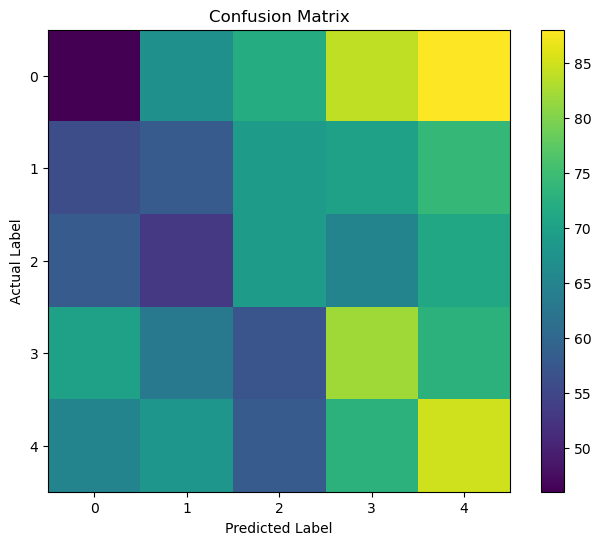

In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Step 10: Saving the Trained Model

To avoid retraining the model every time, the trained Linear SVM model and TF-IDF vectorizer are saved using Joblib. These files will later be used in the Streamlit web application.

In [56]:
import joblib

joblib.dump(svm_model, "../models/classifier.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


# Step 11: Data Visualization

To better understand the dataset, we visualize the distribution of ticket categories and ticket priorities. These visualizations help identify class balance and provide useful insights before model training.

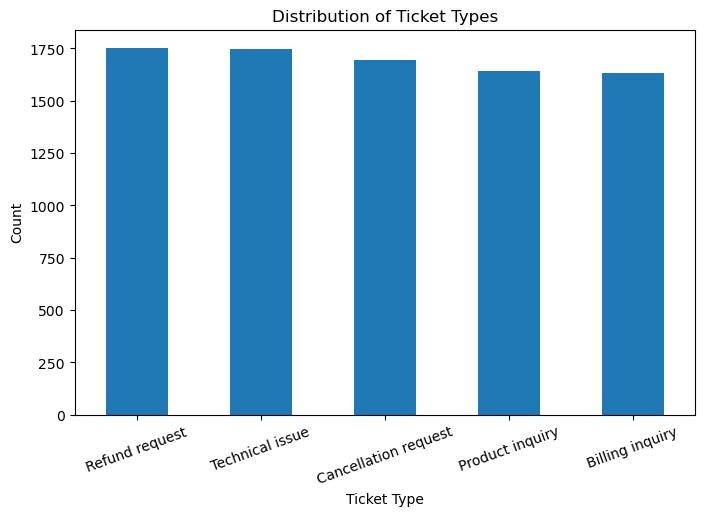

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["Ticket Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

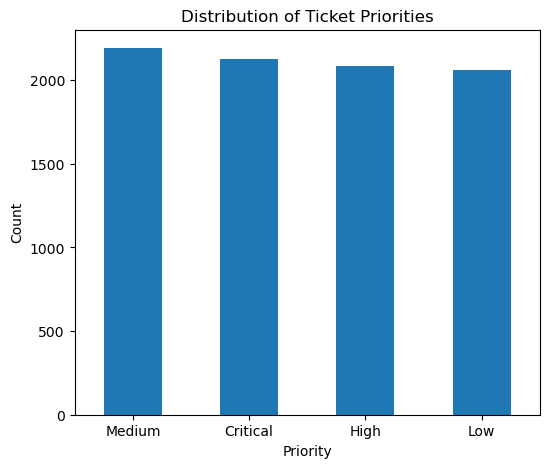

In [58]:
plt.figure(figsize=(6,5))

df["Ticket Priority"].value_counts().plot(kind="bar")

plt.title("Distribution of Ticket Priorities")
plt.xlabel("Priority")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

# Step 12: Model Performance Comparison

Three machine learning algorithms were trained and evaluated. The following chart compares their classification accuracy.

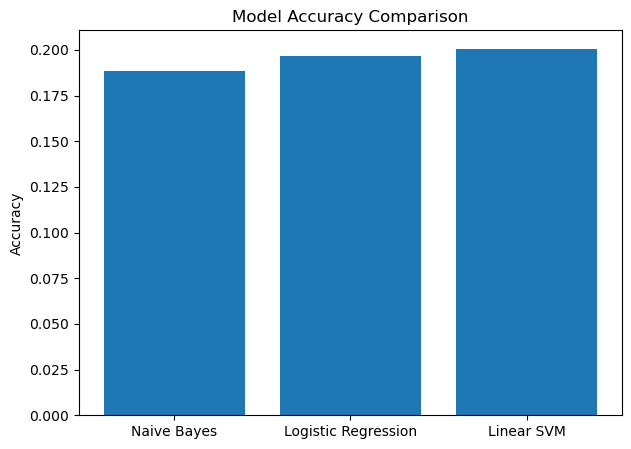

In [59]:
models = ["Naive Bayes", "Logistic Regression", "Linear SVM"]
scores = [nb_accuracy, lr_accuracy, svm_accuracy]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# Step 13: Word Cloud

A word cloud provides a visual representation of the most frequently occurring words in customer support tickets after preprocessing.

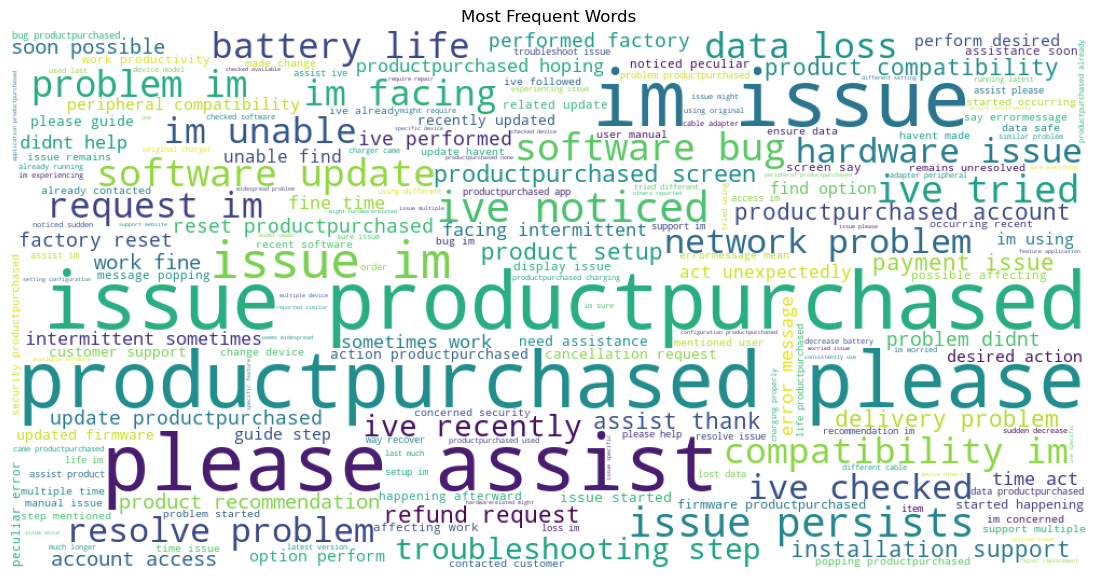

In [62]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.show()

# Project Conclusion

## Objective

The objective of this project was to develop an NLP-based machine learning system capable of automatically classifying customer support tickets into predefined categories.

## Workflow

- Dataset Collection
- Data Exploration
- Text Cleaning
- Tokenization
- Stopword Removal
- Lemmatization
- TF-IDF Feature Extraction
- Model Training
- Model Evaluation
- Model Saving

## Algorithms Used

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

## Result

The Linear SVM model achieved the highest performance among the evaluated models and was selected as the final classifier. The trained model and TF-IDF vectorizer were saved for future deployment.

This project demonstrates a complete Natural Language Processing workflow for automated support ticket classification and can be extended into a real-time customer support system using Streamlit.

In [63]:
X = df["clean_text"]
y = df["Ticket Priority"]

In [64]:
print(y.unique())

['Critical' 'Low' 'High' 'Medium']


In [65]:
from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
X_train_p_tfidf = vectorizer.fit_transform(X_train_p)
X_test_p_tfidf = vectorizer.transform(X_test_p)

In [67]:
print(X_train_p_tfidf.shape)
print(X_test_p_tfidf.shape)

(6775, 5000)
(1694, 5000)


In [69]:
y = df["Ticket Priority"]

In [71]:
# Train Priority Classification Model

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

y_priority = df["Ticket Priority"]

_, _, y_train_priority, y_test_priority = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

priority_model = LinearSVC()

priority_model.fit(X_train_tfidf, y_train_priority)

priority_predictions = priority_model.predict(X_test_tfidf)

priority_accuracy = accuracy_score(
    y_test_priority,
    priority_predictions
)

print("Priority Accuracy:", priority_accuracy)

Priority Accuracy: 0.2361275088547816


In [72]:
joblib.dump(priority_model, "../models/priority_classifier.pkl")

print("Priority model saved successfully!")

Priority model saved successfully!
